# Consulting & IT Employer Reputation Intelligence
## Análisis de reputación de la empleadora de Accenture con NLP sobre reseñas de Glassdoor

Este proyecto evalúa cómo se percibe a Accenture como empleadora comparando la opinión de empleados y ex empleados en Glassdoor con la de competidores clave del sector tecnológico y de consultoría.

La metodología combina procesamiento del lenguaje natural, análisis de sentimiento y modelado de tópicos para identificar los factores que más influyen en la percepción de la marca empleadora, así como las principales áreas de mejora.

**Empresas comparadas:** Accenture, Capgemini, Deloitte, Cognizant Technology Solutions e Infosys.

**Objetivo principal:** detectar patrones de reputación que ayuden a entender fortalezas diferenciales, riesgos de retención y oportunidades para reforzar la propuesta de valor del empleador.

| Sección | Contenido |
|---|---|
| 0 | Carga y preparación |
| 1 | EDA: rating, recomendación, empleados actuales vs. antiguos |
| 2 | Análisis de sentimiento en pros y cons (control de calidad) |
| 3 | Modelado de tópicos con BERTopic |
| 4 | Comparación con peers: peso de cada tópico y balance neto |
| 5 | Empleados actuales vs. antiguos |
| 6 | Conclusiones y recomendaciones para RRHH |

In [ ]:
# En Colab: transformers ya viene instalado; BERTopic no.
# !pip install -q bertopic sentence-transformers

---
## 0. Carga y preparación

In [ ]:
# Cargamos librerías para transformar datos, analizar tablas y crear gráficos.
import re
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Conservamos el nombre tal como aparece en el parquet para que el filtro incluya a Cognizant.
TARGET = 'Accenture'
PEERS = ['Capgemini', 'Deloitte', 'Cognizant-Technology-Solutions', 'Infosys']
FIRMS = [TARGET] + PEERS

# Usamos una etiqueta legible en tablas, gráficos y comparaciones posteriores.
COMPANY_LABELS = {
    'Cognizant-Technology-Solutions': 'Cognizant Technology Solutions'
}
DISPLAY_FIRMS = [COMPANY_LABELS.get(firm, firm) for firm in FIRMS]

# Limitamos la muestra a 1.000 reseñas por empresa para mantener el análisis equilibrado.
MAX_POR_EMPRESA = 1000
SEED = 42

# Leemos solo las empresas del estudio y comprobamos el volumen disponible en la fuente.
base_path = '../data/raw/glassdoor_reviews_hr.parquet'
raw = pd.read_parquet(base_path, filters=[('firm', 'in', FIRMS)])
print('Reseñas disponibles por empresa:')
print(raw['firm'].value_counts().rename(index=COMPANY_LABELS))

# Tomamos una muestra reproducible por empresa y normalizamos el nombre para el análisis.
df = pd.concat([g.sample(n=min(MAX_POR_EMPRESA, len(g)), random_state=SEED)
                for _, g in raw.groupby('firm')], ignore_index=True)
df['firm'] = df['firm'].replace(COMPANY_LABELS)
print(f'\nMuestra de trabajo: {len(df):,} reseñas')

Reseñas disponibles por empresa:
firm
Cognizant Technology Solutions    50877
Accenture                         48332
Deloitte                          40199
Infosys                           35007
Capgemini                         26815
Name: count, dtype: int64

Muestra de trabajo: 5,000 reseñas


La columna `current` mezcla situación y antigüedad (`"Former Employee, more than 3 years"`). La separo en dos variables. También traduzco `recommend` (v = sí, o = sin opinión, x = no) y limpio saltos de línea del texto.

In [15]:
# Convertimos el campo combinado current en situación laboral y antigüedad declarada.
def situacion(s):
    s = str(s).lower()
    if s.startswith('current'):
        return 'Actual'
    if s.startswith('former'):
        return 'Antiguo'
    return 'Desconocido'

def antiguedad(s):
    m = re.search(r'(less|more) than (\d+) year', str(s))
    return f'{m.group(1)} than {m.group(2)}y' if m else 'n/d'

# Traducimos la recomendación y derivamos año, situación y antigüedad para los análisis.
df['situacion'] = df['current'].map(situacion)
df['antiguedad'] = df['current'].map(antiguedad)
df['recomienda'] = df['recommend'].map({'v': 'Sí', 'o': 'Neutral', 'x': 'No'})
df['date_review'] = pd.to_datetime(df['date_review'])
df['anio'] = df['date_review'].dt.year

# Limpiamos whitespace y convertimos nulos o placeholders en textos vacíos, no en palabras del análisis.
for col in ['pros', 'cons']:
    df[col] = (df[col].fillna('').astype(str)
               .str.replace(r'\s+', ' ', regex=True).str.strip()
               .str.replace(r'(?i)^(?:none\s*)+$', '', regex=True))

# Comprobamos el reparto de situación laboral y cuántos textos faltan en cada campo.
print(df['situacion'].value_counts())
print('Filas con pros vacíos:', df['pros'].eq('').sum())
print('Filas con cons vacíos:', df['cons'].eq('').sum())
df[['firm', 'date_review', 'situacion', 'antiguedad', 'overall_rating', 'recomienda', 'pros', 'cons']].head()

situacion
Actual     3519
Antiguo    1481
Name: count, dtype: int64
Filas con pros vacíos: 1
Filas con cons vacíos: 3


,firm,date_review,situacion,antiguedad,overall_rating,recomienda,pros,cons
0,Accenture,2019-01-02,Actual,more than 5y,4.0,Sí,Good to start career and for experienced as we...,"no cons experience , good place for work life ..."
1,Accenture,2021-09-28,Actual,less than 1y,5.0,Sí,Great Start Up for newly grad,
2,Accenture,2020-12-04,Actual,n/d,4.0,Sí,Good training ground and Good people,Salary is lesser compare to other company
3,Accenture,2021-01-19,Antiguo,n/d,5.0,Sí,"good company culture, employee friendly",I feel appraisal cycles are poor
4,Accenture,2021-11-16,Antiguo,less than 1y,4.0,Neutral,"Good work life, limited work","low salary, need to learn the domain they alloted"


---
## 1. EDA

Resumen comparativo por empresa:
                          firm  reseñas  rating_medio  porcentaje_recomendacion  porcentaje_actuales
                     Accenture     1000          4.00                      56.2                 67.4
                      Deloitte     1000          3.91                      47.8                 68.4
                     Capgemini     1000          3.86                      57.7                 75.4
Cognizant Technology Solutions     1000          3.79                      48.1                 68.5
                       Infosys     1000          3.76                      50.9                 72.2

Rating medio por situación laboral:
situacion                       Actual  Antiguo
firm                                           
Accenture                         4.14     3.71
Capgemini                         3.98     3.48
Cognizant Technology Solutions    3.83     3.70
Deloitte                          4.00     3.69
Infosys                           3.

<Figure size 1000x500 with 0 Axes>

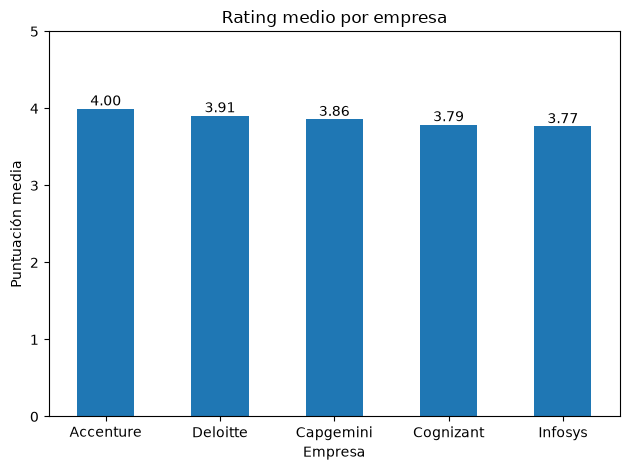

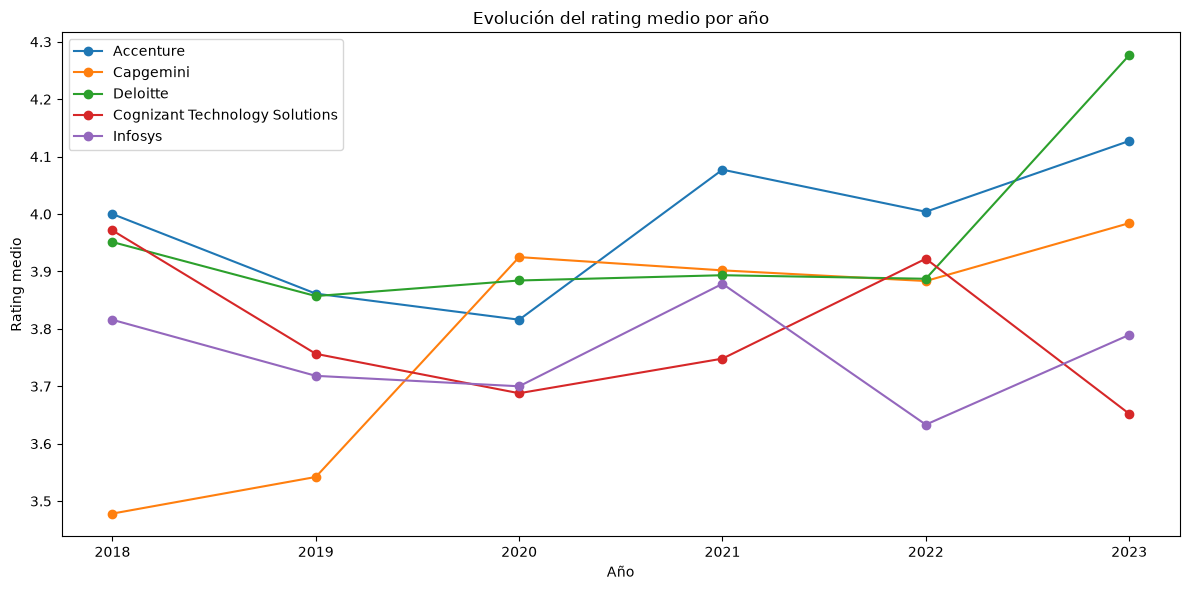


Archivos generados en output/
['Accenture_employer_reputation.pptx', 'Accenture_employer_reputation_v2.pptx', 'eda_summary_by_company.csv', 'evolucion_rating_por_anio.png', 'figures', 'rating_medio_por_empresa.png', 'sentiment_quality_check.csv']


In [17]:
# Preparamos la carpeta de salida para tablas y gráficas del análisis exploratorio.
from pathlib import Path

output_dir = Path('../output')
output_dir.mkdir(exist_ok=True)

# Resumimos volumen, rating, recomendación y proporción de empleados actuales por empresa.
summary = (
    df.groupby('firm')
      .agg(
          reseñas=('firm', 'size'),
          rating_medio=('overall_rating', 'mean'),
          porcentaje_recomendacion=('recomienda', lambda s: (s == 'Sí').mean() * 100),
          porcentaje_actuales=('situacion', lambda s: (s == 'Actual').mean() * 100)
      )
      .reset_index()
      .sort_values('rating_medio', ascending=False)
)

print('Resumen comparativo por empresa:')
print(summary.round(2).to_string(index=False))

# Comparamos el rating medio entre personas que siguen en la empresa y quienes ya salieron.
current_vs_former = (
    df.groupby(['firm', 'situacion'])['overall_rating']
      .mean()
      .unstack()
      .loc[:, ['Actual', 'Antiguo']]
)
print('\nRating medio por situación laboral:')
print(current_vs_former.round(2))

# Visualizamos el rating promedio, manteniendo la escala original de 1 a 5.
plt.figure(figsize=(10, 5))
ax = summary.plot(kind='bar', x='firm', y='rating_medio', color='#1f77b4', legend=False)
ax.set_title('Rating medio por empresa')
ax.set_ylabel('Puntuación media')
ax.set_xlabel('Empresa')
ax.set_ylim(0, 5)
ax.set_xticklabels(
    summary['firm'].replace({'Cognizant Technology Solutions': 'Cognizant'}),
    rotation=0
)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(output_dir / 'rating_medio_por_empresa.png', dpi=200)
plt.show()

# Calculamos y graficamos la evolución anual del rating para las cinco empresas.
trend = (
    df.groupby(['anio', 'firm'])['overall_rating']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))
for company in DISPLAY_FIRMS:
    subset = trend[trend['firm'] == company].sort_values('anio')
    plt.plot(subset['anio'], subset['overall_rating'], marker='o', label=company)

plt.title('Evolución del rating medio por año')
plt.xlabel('Año')
plt.ylabel('Rating medio')
plt.xticks(sorted(df['anio'].unique()))
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / 'evolucion_rating_por_anio.png', dpi=200)
plt.show()

# Guardamos el resumen tabular para reutilizarlo en el informe y la presentación.
summary.to_csv(output_dir / 'eda_summary_by_company.csv', index=False)
print('\nArchivos generados en output/')
print(sorted(p.name for p in output_dir.iterdir()))

### Lectura provisional del EDA

- **Rating general:** en esta muestra equilibrada de 1.000 reseñas por empresa, Accenture presenta el rating medio más alto (4,00), seguida de Deloitte (3,91), Capgemini (3,86), Cognizant Technology Solutions (3,79) e Infosys (3,76).
- **Recomendación:** Capgemini registra el mayor porcentaje de recomendaciones (57,7%), ligeramente por encima de Accenture (56,2%). El rating medio más alto no implica, por sí solo, la mayor intención de recomendar.
- **Situación laboral:** el rating de empleados antiguos es inferior al de empleados actuales en las cinco firmas. La diferencia observada va de 0,13 puntos en Cognizant a 0,50 en Capgemini; en Accenture es de 0,43.
- **Cautela:** son diferencias descriptivas de una muestra de reseñas, no pruebas de significación ni estimaciones causales. Se revisarán junto con los temas textuales y el volumen disponible por año antes de extraer conclusiones.

---
## 2. Control orientativo de polaridad en pros y cons

Los campos `pros` y `cons` suelen expresar valoraciones, pero también pueden contener texto neutro, ambiguo o vacío. Para revisar su polaridad predominante, aplicamos el modelo preentrenado `distilbert-base-uncased-finetuned-sst-2-english` a cada fragmento disponible.

El modelo es binario (positivo o negativo), no dispone de clase neutral y puede perder contexto en frases breves, irónicas o con varias ideas. Se truncan los textos al límite que admite el modelo. Por ello, estos porcentajes son un control orientativo y no una medida definitiva del sentimiento.

Calculamos el porcentaje de pros etiquetados como positivos y de cons etiquetados como negativos, excluyendo textos vacíos. La polaridad contraria al campo se inspecciona caso por caso: en `cons`, por ejemplo, “no cons” puede estar correctamente clasificado como positivo, no ser un error del modelo.

In [19]:
# Cargamos el clasificador binario preentrenado para comprobar la polaridad de pros y cons.
from transformers import pipeline

MODEL_SENTIMIENTO = 'distilbert-base-uncased-finetuned-sst-2-english'
sentiment_model = pipeline(
    'sentiment-analysis',
    model=MODEL_SENTIMIENTO,
    tokenizer=MODEL_SENTIMIENTO
)


# Aplicamos el modelo solo a textos no vacíos y conservamos puntuación y confianza por reseña.
def classify_texts(texts):
    valid_texts = texts.fillna('').astype(str).str.strip()
    valid_texts = valid_texts[valid_texts.ne('')]
    predictions = sentiment_model(
        valid_texts.tolist(),
        truncation=True,
        batch_size=32
    )

    result = pd.DataFrame(index=texts.index, columns=['sentiment', 'confidence'])
    result.loc[valid_texts.index, 'sentiment'] = [
        prediction['label'].title() for prediction in predictions
    ]
    result.loc[valid_texts.index, 'confidence'] = [
        prediction['score'] for prediction in predictions
    ]
    result['confidence'] = pd.to_numeric(result['confidence'], errors='coerce')
    return result


# Clasificamos ambos campos por separado y añadimos los resultados a la tabla de reseñas.
pros_predictions = classify_texts(df['pros'])
cons_predictions = classify_texts(df['cons'])
df['pros_sentiment'] = pros_predictions['sentiment']
df['pros_confidence'] = pros_predictions['confidence']
df['cons_sentiment'] = cons_predictions['sentiment']
df['cons_confidence'] = cons_predictions['confidence']

# Calculamos el porcentaje esperado solo entre textos que recibieron una clasificación.
pros_scored = df['pros_sentiment'].notna()
cons_scored = df['cons_sentiment'].notna()
pros_positive = df.loc[pros_scored, 'pros_sentiment'].eq('Positive').mean() * 100
cons_negative = df.loc[cons_scored, 'cons_sentiment'].eq('Negative').mean() * 100

print(f'Textos pros analizados: {pros_scored.sum():,}')
print(f'Textos cons analizados: {cons_scored.sum():,}')
print(f'% de pros clasificados como positivos: {pros_positive:.2f}%')
print(f'% de cons clasificados como negativos: {cons_negative:.2f}%')

# Inspeccionamos ejemplos donde la etiqueta contradice la polaridad esperada del campo.
discordant_pros = df.loc[
    df['pros_sentiment'].eq('Negative'),
    ['firm', 'pros', 'pros_sentiment', 'pros_confidence']
].head(10)
discordant_cons = df.loc[
    df['cons_sentiment'].eq('Positive'),
    ['firm', 'cons', 'cons_sentiment', 'cons_confidence']
].head(10)

print('\nEjemplos de pros clasificados como negativos:')
print(discordant_pros.to_string(index=False))
print('\nEjemplos de cons clasificados como positivos:')
print(discordant_cons.to_string(index=False))

# Exportamos las dos métricas globales como control resumido del bloque.
sentiment_quality = pd.DataFrame({
    'metric': ['pros_positives_pct', 'cons_negatives_pct'],
    'value': [pros_positive, cons_negative]
})
sentiment_quality.to_csv('../output/sentiment_quality_check.csv', index=False)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Textos pros analizados: 4,999
Textos cons analizados: 4,997
% de pros clasificados como positivos: 92.46%
% de cons clasificados como negativos: 80.53%

Ejemplos de pros clasificados como negativos:
     firm                                                                                                                                            pros pros_sentiment  pros_confidence
Accenture *Very easy job once getting used to it (reviewing content on a daily basis). *Working 5 hours per day (2 hours for wellness + 1 hour for Lunch)       Negative         0.751512
Accenture                                                                                              Women importance. Cab facilities. Time management.       Negative         0.907231
Accenture                                                                                                                   1.Nothing i can find till now       Negative         0.999400
Accenture                                                

### Lectura del control de polaridad

- De 4.999 pros con texto, el 92,46% recibe etiqueta positiva; de 4.997 cons, el 80,53% recibe etiqueta negativa. La mayor parte de ambos campos coincide con la polaridad esperada, aunque queda un grupo relevante de excepciones.
- La etiqueta contraria no equivale automáticamente a un error: algunos cons positivos dicen explícitamente que no hay aspectos negativos. Otros ejemplos sí revelan pérdida de contexto o frases con varias ideas.
- La confianza del modelo no es una garantía de acierto. Usaremos este bloque como control descriptivo, no como resultado sustantivo ni como filtro para eliminar reseñas.

---
## 3. Modelado de tópicos con BERTopic

Entreno dos modelos comunes a las cinco empresas: uno con los textos de `pros` y otro con los de `cons`. De este modo, los tópicos de cada conjunto se pueden comparar entre empresas; los tópicos de pros y cons no se asumirán equivalentes entre sí.

Antes de entrenar, revisaré por empresa la cantidad de textos utilizables, los vacíos, las longitudes y los duplicados. Después inspeccionaremos palabras representativas y ejemplos reales de cada tópico. Las etiquetas de negocio se asignarán solo cuando los ejemplos las respalden; los textos agrupados como ruido (`-1`) se informarán aparte.

Los porcentajes se calcularán sobre textos no vacíos y se acompañarán del volumen analizado. Serán distribuciones descriptivas de esta muestra, no estimaciones causales ni porcentajes de toda la plantilla.

In [18]:
# Reunimos pros y cons en una tabla larga, conservando la empresa y situación laboral.
review_metadata = df[['firm', 'situacion']].copy()
review_metadata['review_id'] = df.index
topic_docs = pd.concat(
    [
        review_metadata.join(df[['pros']]).rename(columns={'pros': 'text'}).assign(tipo='pros'),
        review_metadata.join(df[['cons']]).rename(columns={'cons': 'text'}).assign(tipo='cons')
    ],
    ignore_index=True
)

# Normalizamos espacios y excluimos textos vacíos antes de contar documentos analizables.
topic_docs['text'] = topic_docs['text'].fillna('').astype(str).str.strip()
topic_docs['n_caracteres'] = topic_docs['text'].str.len()
topic_docs['texto_valido'] = topic_docs['text'].ne('')

# Resumimos cobertura, longitud y repetición por campo y empresa para detectar sesgos de entrada.
topic_diagnostics = (
    topic_docs.groupby(['tipo', 'firm'])
    .agg(
        textos_validos=('texto_valido', 'sum'),
        textos_vacios=('texto_valido', lambda values: (~values).sum()),
        mediana_caracteres=('n_caracteres', lambda lengths: lengths[topic_docs.loc[lengths.index, 'texto_valido']].median()),
        textos_cortos=('n_caracteres', lambda lengths: (lengths[topic_docs.loc[lengths.index, 'texto_valido']] < 10).sum()),
        duplicados=('text', lambda texts: texts[texts.ne('')].duplicated().sum())
    )
    .reset_index()
)

print('Diagnóstico de textos que entrarán en cada modelo:')
print(topic_diagnostics.to_string(index=False))

Diagnóstico de textos que entrarán en cada modelo:
tipo                           firm  textos_validos  textos_vacios  mediana_caracteres  textos_cortos  duplicados
cons                      Accenture             998              2                45.0              2           1
cons                      Capgemini            1000              0                44.0              0           2
cons Cognizant Technology Solutions             999              1                40.0              0           2
cons                       Deloitte            1000              0                45.0              0           0
cons                        Infosys            1000              0                42.0              0           3
pros                      Accenture            1000              0                47.0              0           2
pros                      Capgemini            1000              0                48.0              0           2
pros Cognizant Technology Solutions  

### Lectura del diagnóstico de textos

- La muestra está equilibrada: hay 1.000 reseñas por empresa. Para tópicos se usarán 4.999 pros y 4.997 cons no vacíos; dos cons de Accenture y un pros y un cons de Cognizant se excluyen por estar vacíos.
- Las longitudes medianas oscilan entre 40 y 49 caracteres. Son fragmentos breves, por lo que algunos tópicos podrían reflejar frases generales o poco contexto; habrá que contrastar palabras y ejemplos antes de etiquetarlos.
- Los duplicados exactos son escasos en esta muestra. Se conservarán para no alterar el peso de las menciones repetidas; no parecen justificar una deduplicación previa.

In [36]:
# Probamos BERTopic primero con una muestra equilibrada para revisar coherencia sin entrenar aún con todos los textos.
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP

N_PILOTO_POR_EMPRESA = 200
MIN_TAMANO_TOPIC_PILOTO = 10
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# Seleccionamos el mismo número de textos por empresa y tipo para evitar que una firma domine el piloto.
pilot_docs = (
    topic_docs.loc[topic_docs['texto_valido']]
    .groupby(['tipo', 'firm'], group_keys=False)
    .sample(n=N_PILOTO_POR_EMPRESA, random_state=SEED)
    .reset_index(drop=True)
)

# Ajustamos un modelo compartido por campo con UMAP reproducible para poder revisar los mismos tópicos.
pilot_models = {}
pilot_assignments = []
for tipo in ['pros', 'cons']:
    subset = pilot_docs.loc[pilot_docs['tipo'].eq(tipo)].copy()
    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2
    )
    model = BERTopic(
        embedding_model=EMBEDDING_MODEL,
        vectorizer_model=vectorizer,
        umap_model=UMAP(random_state=SEED),
        min_topic_size=MIN_TAMANO_TOPIC_PILOTO,
        calculate_probabilities=False,
        verbose=True
    )
    topics, _ = model.fit_transform(subset['text'].tolist())
    subset['topic_id'] = topics
    pilot_models[tipo] = model
    pilot_assignments.append(subset)

# Conservamos metadatos y asignaciones para inspeccionar cobertura por empresa y ejemplos reales.
pilot_assignments = pd.concat(pilot_assignments, ignore_index=True)
for tipo, model in pilot_models.items():
    print(f'\nTópicos piloto de {tipo}:')
    print(model.get_topic_info()[['Topic', 'Count', 'Name']].to_string(index=False))

2026-10-02 05:15:25,656 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-10-02 05:15:32,608 - BERTopic - Embedding - Completed ✓
2026-10-02 05:15:32,613 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:15:37,224 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:15:37,225 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:15:37,258 - BERTopic - Cluster - Completed ✓
2026-10-02 05:15:37,263 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:15:37,306 - BERTopic - Representation - Completed ✓
2026-10-02 05:15:37,397 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-10-02 05:15:50,247 - BERTopic - Embedding - Completed ✓
2026-10-02 05:15:50,250 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:15:54,034 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:15:54,036 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:15:54,070 - BERTopic - Cluster - Completed ✓
2026-10-02 05:15:54,077 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:15:54,133 - BERTopic - Representation - Completed ✓



Tópicos piloto de pros:
 Topic  Count                                                     Name
    -1    359                               -1_good_work_great_company
     0    103                 0_culture_work culture_culture good_work
     1     74                      1_benefits_salary_pay_good benefits
     2     68 2_environment_work environment_environment work_friendly
     3     65    3_learning_learn_learning opportunities_good learning
     4     55         4_company_good company_company work_company good
     5     52                    5_balance_work life_life balance_life
     6     35                6_place work_place_good place_great place
     7     33                          7_team_project_projects_members
     8     23              8_training_good training_training good_good
     9     18          9_hours_flexible_working hours_flexible working
    10     17      10_networking_lots opportunities_lots_opportunities
    11     16         11_good experience_experience_

In [38]:
# Revisamos palabras y reseñas reales de los tópicos más frecuentes antes de asignar etiquetas de negocio.
N_TOPICS_TO_REVIEW = 8

for tipo, model in pilot_models.items():
    print(f'\nEjemplos representativos de {tipo}:')
    topic_info = model.get_topic_info()
    topics_to_review = topic_info.loc[topic_info['Topic'].ne(-1)].nlargest(
        N_TOPICS_TO_REVIEW, 'Count'
    )

    for topic_id in topics_to_review['Topic']:
        terms = ', '.join(term for term, _ in model.get_topic(topic_id)[:6])
        examples = (
            pilot_assignments.loc[
                pilot_assignments['tipo'].eq(tipo)
                & pilot_assignments['topic_id'].eq(topic_id),
                ['firm', 'text']
            ]
            .groupby('firm', group_keys=False)
            .head(1)
        )
        print(f'\nTópico {topic_id} | términos: {terms}')
        print(examples.to_string(index=False, max_colwidth=180))

# Medimos en cuántas empresas aparece cada tópico no residual; la comparación seguirá usando proporciones.
pilot_topic_coverage = (
    pilot_assignments.loc[pilot_assignments['topic_id'].ne(-1)]
    .groupby(['tipo', 'topic_id'])
    .agg(empresas_con_tema=('firm', 'nunique'), reseñas=('review_id', 'size'))
    .reset_index()
)
print('\nCobertura empresarial de los tópicos piloto:')
print(pilot_topic_coverage.to_string(index=False))


Ejemplos representativos de pros:

Tópico 0 | términos: culture, work culture, culture good, work, good work, good
                          firm                                                                                 text
                     Accenture                            Great people, strong assets and various kinds of projects
                     Capgemini                                                  Good, culture, timing, office, work
Cognizant Technology Solutions Company culture Work culture Salary Hikes compared to other service based companies.
                      Deloitte                                             no micromanagement, amazing work culture
                       Infosys                                                   Our work is noticed and recognised

Tópico 1 | términos: benefits, salary, pay, good benefits, good, bonus
                          firm                                                                                      

### Lectura provisional del piloto

- Los ejemplos equilibrados sugieren temas transversales: en pros aparecen cultura, compensación, entorno, aprendizaje y conciliación; en cons aparecen salario, jornada, proyectos y crecimiento. Los términos y ejemplos se revisaron entre las cinco firmas.
- Con UMAP reproducible y la configuración inicial, el piloto asignó al grupo residual `-1` 359 de 1.000 pros (35,9%) y 354 de 1.000 cons (35,4%).
- La prueba de sensibilidad con `min_cluster_size=35` mostró que `min_samples=5` reduce el residual de pros del 49,1% al 24,3%, pero lo eleva en cons del 0% al 19,6%; a cambio, genera nueve tópicos de cons en vez de solo dos. Mantengo esta opción por su mayor detalle temático y mostraré siempre el residual.
- Los ejemplos de “no cons” o “nothing so far” expresan ausencia de queja; son respuestas válidas, pero no categorías de problema. Los IDs del piloto no se reutilizan como etiquetas del modelo completo.

In [39]:
# Comparamos dos ajustes sobre los mismos textos y UMAP reproducible; solo cambia min_samples.
from hdbscan import HDBSCAN

MIN_CLUSTER_SIZE_TEST = 35
pilot_parameter_results = {}
for configuration, min_samples in [('default', None), ('min_samples_5', 5)]:
    rows = []
    for tipo in ['pros', 'cons']:
        subset = pilot_docs.loc[pilot_docs['tipo'].eq(tipo)].copy()
        vectorizer = CountVectorizer(
            stop_words='english',
            ngram_range=(1, 2),
            min_df=2
        )
        clusterer = HDBSCAN(
            min_cluster_size=MIN_CLUSTER_SIZE_TEST,
            min_samples=min_samples,
            prediction_data=True
        )
        model = BERTopic(
            embedding_model=EMBEDDING_MODEL,
            vectorizer_model=vectorizer,
            umap_model=UMAP(random_state=SEED),
            hdbscan_model=clusterer,
            calculate_probabilities=False,
            verbose=True
        )
        topics, _ = model.fit_transform(subset['text'].tolist())
        rows.append(pd.DataFrame({'tipo': tipo, 'topic_id': topics}))
    pilot_parameter_results[configuration] = pd.concat(rows, ignore_index=True)

# Comparamos ruido y número de tópicos, manteniendo fijo min_cluster_size=35.
parameter_comparison = []
for tipo in ['pros', 'cons']:
    result = {'tipo': tipo}
    for configuration, assignments in pilot_parameter_results.items():
        topics = assignments.loc[assignments['tipo'].eq(tipo), 'topic_id']
        result[f'ruido_{configuration}_pct'] = topics.eq(-1).mean() * 100
        result[f'topicos_{configuration}'] = topics.loc[topics.ne(-1)].nunique()
    parameter_comparison.append(result)
print(pd.DataFrame(parameter_comparison).round(2).to_string(index=False))

2026-10-02 05:17:36,439 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-10-02 05:17:48,473 - BERTopic - Embedding - Completed ✓
2026-10-02 05:17:48,475 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:17:52,014 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:17:52,018 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:17:52,062 - BERTopic - Cluster - Completed ✓
2026-10-02 05:17:52,075 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:17:52,118 - BERTopic - Representation - Completed ✓
2026-10-02 05:17:52,188 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

2026-10-02 05:18:12,690 - BERTopic - Embedding - Completed ✓
2026-10-02 05:18:12,691 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:18:15,618 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:18:15,619 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:18:15,641 - BERTopic - Cluster - Completed ✓
2026-10-02 05:18:15,645 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:18:15,674 - BERTopic - Representation - Completed ✓
2026-10-02 05:18:15,725 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-10-02 05:18:32,368 - BERTopic - Embedding - Completed ✓
2026-10-02 05:18:32,370 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:18:36,438 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:18:36,440 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:18:36,475 - BERTopic - Cluster - Completed ✓
2026-10-02 05:18:36,480 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:18:36,526 - BERTopic - Representation - Completed ✓


tipo  ruido_default_pct  topicos_default  ruido_min_samples_5_pct  topicos_min_samples_5
pros               49.1                7                     24.3                      8
cons                0.0                2                     19.6                      9


In [40]:
# Ajustamos dos modelos finales sobre todos los textos válidos, manteniendo un modelo compartido por campo.
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from umap import UMAP

MIN_TAMANO_TOPIC = 35
MIN_SAMPLES = 5
REPRESENTATION_STOP_WORDS = sorted(
    set(ENGLISH_STOP_WORDS).union({'good', 'great', 'nice', 'company'})
)

# Calculamos cada texto una sola vez y conservamos empresa, reseña y situación para análisis posteriores.
topic_models = {}
assignment_frames = []
for tipo in ['pros', 'cons']:
    subset = topic_docs.loc[
        topic_docs['tipo'].eq(tipo) & topic_docs['texto_valido']
    ].copy()
    vectorizer = CountVectorizer(
        stop_words=REPRESENTATION_STOP_WORDS,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.85
    )
    clusterer = HDBSCAN(
        min_cluster_size=MIN_TAMANO_TOPIC,
        min_samples=MIN_SAMPLES,
        prediction_data=True
    )
    model = BERTopic(
        embedding_model=EMBEDDING_MODEL,
        vectorizer_model=vectorizer,
        umap_model=UMAP(random_state=SEED),
        hdbscan_model=clusterer,
        calculate_probabilities=False,
        verbose=True
    )
    topics, _ = model.fit_transform(subset['text'].tolist())
    subset['topic_id'] = topics
    topic_models[tipo] = model
    assignment_frames.append(subset)

# Combinamos las dos asignaciones sin asumir que un ID de pros equivale a uno de cons.
topic_assignments = pd.concat(assignment_frames, ignore_index=True)

# Generamos nombres automáticos y recuentos globales para inspeccionar primero los temas más frecuentes.
topic_names = []
for tipo, model in topic_models.items():
    info = model.get_topic_info()[['Topic', 'Name']].rename(
        columns={'Topic': 'topic_id', 'Name': 'nombre_automatico'}
    )
    info['tipo'] = tipo
    topic_names.append(info)
topic_names = pd.concat(topic_names, ignore_index=True)

topic_global_summary = (
    topic_assignments.groupby(['tipo', 'topic_id'])
    .size()
    .rename('textos')
    .reset_index()
    .merge(topic_names, on=['tipo', 'topic_id'], how='left')
)
topic_global_summary['porcentaje'] = (
    topic_global_summary['textos']
    / topic_global_summary.groupby('tipo')['textos'].transform('sum')
    * 100
)

for tipo in ['pros', 'cons']:
    print(f'\nDistribución global de tópicos para {tipo}:')
    print(
        topic_global_summary.loc[topic_global_summary['tipo'].eq(tipo)]
        .sort_values('textos', ascending=False)
        .head(20)
        .round({'porcentaje': 2})
        .to_string(index=False)
    )

# Calculamos porcentajes por empresa con todos los textos válidos, incluido el ruido -1, en el denominador.
topic_distribution = (
    topic_assignments.groupby(['tipo', 'firm', 'topic_id'])
    .size()
    .rename('textos')
    .reset_index()
)
topic_distribution['textos_validos_empresa'] = topic_distribution.groupby(
    ['tipo', 'firm']
)['textos'].transform('sum')
topic_distribution['porcentaje'] = (
    topic_distribution['textos'] / topic_distribution['textos_validos_empresa'] * 100
)
topic_distribution = topic_distribution.merge(
    topic_names, on=['tipo', 'topic_id'], how='left'
)

# Guardamos asignaciones y resúmenes sin copiar los textos originales a los archivos de salida.
topic_assignments.drop(columns=['text', 'n_caracteres', 'texto_valido']).to_csv(
    '../output/topic_assignments.csv', index=False
)
topic_distribution.to_csv('../output/topic_distribution_by_company.csv', index=False)
topic_global_summary.to_csv('../output/topic_global_summary.csv', index=False)
print('\nArchivos de tópicos guardados en output/.')

2026-10-02 05:18:45,933 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-10-02 05:19:19,291 - BERTopic - Embedding - Completed ✓
2026-10-02 05:19:19,293 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:19:36,861 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:19:36,862 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:19:36,962 - BERTopic - Cluster - Completed ✓
2026-10-02 05:19:36,970 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:19:37,059 - BERTopic - Representation - Completed ✓
2026-10-02 05:19:37,221 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-10-02 05:20:27,967 - BERTopic - Embedding - Completed ✓
2026-10-02 05:20:27,971 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-02 05:20:36,720 - BERTopic - Dimensionality - Completed ✓
2026-10-02 05:20:36,722 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-02 05:20:36,826 - BERTopic - Cluster - Completed ✓
2026-10-02 05:20:36,830 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-02 05:20:36,948 - BERTopic - Representation - Completed ✓



Distribución global de tópicos para pros:
tipo  topic_id  textos                                                nombre_automatico  porcentaje
pros        -1    1245                           -1_balance_life_life balance_work life       24.90
pros         0     572                                 0_training_learning_learn_growth       11.44
pros         1     437              1_culture_work culture_culture work_working culture        8.74
pros         2     343 2_work environment_environment work_friendly_working environment        6.86
pros         3     278                               3_salary_benefits_pay_compensation        5.56
pros         4     165                                4_flexible_hours_pressure_timings        3.30
pros         5     138                            5_work life_life_life balance_balance        2.76
pros         6     135                            6_clients_client_consulting_different        2.70
pros         7     123                                7_c

In [41]:
# Inspeccionamos los tópicos más frecuentes del corpus completo y ejemplos repartidos entre empresas.
N_TOPICS_TO_REVIEW_FINAL = 10
for tipo, model in topic_models.items():
    print(f'\nEjemplos del modelo completo de {tipo}:')
    top_topics = (
        topic_global_summary.loc[
            topic_global_summary['tipo'].eq(tipo)
            & topic_global_summary['topic_id'].ne(-1)
        ]
        .nlargest(N_TOPICS_TO_REVIEW_FINAL, 'textos')
    )
    for _, topic_row in top_topics.iterrows():
        topic_id = topic_row['topic_id']
        terms = ', '.join(term for term, _ in model.get_topic(topic_id)[:6])
        examples = (
            topic_assignments.loc[
                topic_assignments['tipo'].eq(tipo)
                & topic_assignments['topic_id'].eq(topic_id),
                ['firm', 'text']
            ]
            .groupby('firm', group_keys=False)
            .sample(n=1, random_state=SEED)
        )
        print(
            f"\nTópico {topic_id} | {topic_row['porcentaje']:.2f}% | "
            f"{terms}"
        )
        print(examples.to_string(index=False, max_colwidth=160))

# Cuantificamos el ruido por firma para comprobar si afecta de forma desigual a la comparación.
noise_by_company = (
    topic_assignments.assign(es_ruido=topic_assignments['topic_id'].eq(-1))
    .groupby(['tipo', 'firm'])['es_ruido']
    .mean()
    .mul(100)
    .rename('ruido_pct')
    .reset_index()
)
print('\nPorcentaje de textos sin tópico asignado (-1):')
print(noise_by_company.round(2).to_string(index=False))


Ejemplos del modelo completo de pros:

Tópico 0 | 11.44% | training, learning, learn, growth, career, lot
                          firm                                                                                                                                                             text
                     Accenture Learning curve is very steep Smart colleagues High c-level visibility You get to understand each business big picture You get to understand which industries ...
                     Capgemini                                                                                                                                Management is ok..growth is there
Cognizant Technology Solutions                                                                                                                           good but few issues with opportunities
                      Deloitte                                                                                               

In [42]:
# Listamos todos los tópicos y tamaños para no dejar sin revisar los grupos menos frecuentes.
for tipo, model in topic_models.items():
    print(f'\nInventario completo de tópicos para {tipo}:')
    print(
        topic_global_summary.loc[topic_global_summary['tipo'].eq(tipo)]
        .sort_values('topic_id')
        [['topic_id', 'textos', 'porcentaje', 'nombre_automatico']]
        .round({'porcentaje': 2})
        .to_string(index=False)
    )


Inventario completo de tópicos para pros:
 topic_id  textos  porcentaje                                                nombre_automatico
       -1    1245       24.90                           -1_balance_life_life balance_work life
        0     572       11.44                                 0_training_learning_learn_growth
        1     437        8.74              1_culture_work culture_culture work_working culture
        2     343        6.86 2_work environment_environment work_friendly_working environment
        3     278        5.56                               3_salary_benefits_pay_compensation
        4     165        3.30                                4_flexible_hours_pressure_timings
        5     138        2.76                            5_work life_life_life balance_balance
        6     135        2.70                            6_clients_client_consulting_different
        7     123        2.46                                7_campus_facilities_campuses_food
       

In [43]:
# Traducimos los IDs de esta ejecución reproducible a categorías comunes; las etiquetas son provisionales.
BUSINESS_TOPIC_MAP = {
    'pros': {
        -1: 'Sin tópico asignado',
        0: 'Carrera, crecimiento y aprendizaje',
        1: 'Cultura, liderazgo y gestión',
        2: 'Entorno, equipo e instalaciones',
        3: 'Compensación y beneficios',
        4: 'Conciliación, jornada y flexibilidad',
        5: 'Conciliación, jornada y flexibilidad',
        6: 'Proyectos, clientes y asignación',
        7: 'Entorno, equipo e instalaciones',
        8: 'Conciliación, jornada y flexibilidad',
        9: 'Entorno, equipo e instalaciones',
        10: 'Experiencia general / otros',
        11: 'Experiencia general / otros',
        12: 'Proyectos, clientes y asignación',
        13: 'Experiencia general / otros',
        14: 'Carrera, crecimiento y aprendizaje',
        15: 'Experiencia general / otros',
        16: 'Otros temas por revisar',
        17: 'Entorno, equipo e instalaciones',
        18: 'Cultura, liderazgo y gestión',
        19: 'Otros temas por revisar',
        20: 'Compensación y beneficios',
        21: 'Carrera, crecimiento y aprendizaje',
        22: 'Cultura, liderazgo y gestión',
        23: 'Estabilidad laboral',
        24: 'Otros temas por revisar',
        25: 'Carrera, crecimiento y aprendizaje',
        26: 'Tecnología y herramientas',
        27: 'Carrera, crecimiento y aprendizaje',
        28: 'Otros temas por revisar',
        29: 'Carrera, crecimiento y aprendizaje',
        30: 'Otros temas por revisar',
        31: 'Carrera, crecimiento y aprendizaje',
        32: 'Conciliación, jornada y flexibilidad',
        33: 'Proyectos, clientes y asignación'
    },
    'cons': {
        -1: 'Sin tópico asignado',
        0: 'Compensación y beneficios',
        1: 'Sin desventaja mencionada',
        2: 'Proyectos, clientes y asignación',
        3: 'Cultura, liderazgo y gestión',
        4: 'Compensación y beneficios',
        5: 'Sin desventaja mencionada',
        6: 'Conciliación, jornada y flexibilidad',
        7: 'Compensación y beneficios',
        8: 'Sin desventaja mencionada',
        9: 'Carrera, crecimiento y aprendizaje',
        10: 'Conciliación, jornada y flexibilidad',
        11: 'Conciliación, jornada y flexibilidad',
        12: 'Entorno, equipo e instalaciones',
        13: 'Cultura, liderazgo y gestión',
        14: 'Proyectos, clientes y asignación',
        15: 'Carrera, crecimiento y aprendizaje',
        16: 'Conciliación, jornada y flexibilidad',
        17: 'Carrera, crecimiento y aprendizaje',
        18: 'Carrera, crecimiento y aprendizaje',
        19: 'Carrera, crecimiento y aprendizaje',
        20: 'Carrera, crecimiento y aprendizaje',
        21: 'Cultura, liderazgo y gestión',
        22: 'Conciliación, jornada y flexibilidad',
        23: 'Proyectos, clientes y asignación',
        24: 'Conciliación, jornada y flexibilidad',
        25: 'Compensación y beneficios',
        26: 'Conciliación, jornada y flexibilidad',
        27: 'Carrera, crecimiento y aprendizaje',
        28: 'Conciliación, jornada y flexibilidad',
        29: 'Otros temas por revisar',
        30: 'Cultura, liderazgo y gestión',
        31: 'Tecnología y herramientas',
        32: 'Otros temas por revisar'
    }
}

# Asignamos a cada tópico su categoría; los IDs desconocidos quedan visibles como pendientes.
topic_assignments['categoria_negocio'] = topic_assignments.apply(
    lambda row: BUSINESS_TOPIC_MAP[row['tipo']].get(
        row['topic_id'], 'Otros temas por revisar'
    ),
    axis=1
)
topic_distribution['categoria_negocio'] = topic_distribution.apply(
    lambda row: BUSINESS_TOPIC_MAP[row['tipo']].get(
        row['topic_id'], 'Otros temas por revisar'
    ),
    axis=1
)
unmapped_topic_ids = [
    (tipo, int(topic_id))
    for tipo in ['pros', 'cons']
    for topic_id in topic_assignments.loc[
        topic_assignments['tipo'].eq(tipo), 'topic_id'
    ].unique()
    if topic_id not in BUSINESS_TOPIC_MAP[tipo]
]
print('IDs sin etiqueta manual (quedan en Otros temas por revisar):', unmapped_topic_ids)

# Sumamos tópicos mapeados y mantenemos todos los textos válidos en el denominador.
business_distribution = (
    topic_assignments.groupby(['tipo', 'firm', 'categoria_negocio'])
    .size()
    .rename('textos')
    .reset_index()
)
business_distribution['textos_validos_empresa'] = business_distribution.groupby(
    ['tipo', 'firm']
)['textos'].transform('sum')
business_distribution['porcentaje'] = (
    business_distribution['textos']
    / business_distribution['textos_validos_empresa']
    * 100
)

# Restamos porcentajes solo tras unificar el nombre de cada categoría en pros y cons.
net_balance = business_distribution.pivot_table(
    index=['firm', 'categoria_negocio'],
    columns='tipo',
    values='porcentaje',
    fill_value=0
).reset_index()
for tipo in ['pros', 'cons']:
    if tipo not in net_balance.columns:
        net_balance[tipo] = 0.0
EXCLUDED_FROM_NET = {
    'Sin tópico asignado',
    'Sin desventaja mencionada',
    'Experiencia general / otros',
    'Otros temas por revisar'
}
net_balance['balance_neto_pp'] = net_balance['pros'] - net_balance['cons']
net_balance['incluible_en_balance'] = ~net_balance['categoria_negocio'].isin(
    EXCLUDED_FROM_NET
)

# Exportamos los resultados tabulares sin copiar los textos originales a los CSV.
topic_assignments.drop(columns=['text', 'n_caracteres', 'texto_valido']).to_csv(
    '../output/topic_assignments.csv', index=False
)
topic_distribution.to_csv('../output/topic_distribution_by_company.csv', index=False)
business_distribution.to_csv('../output/business_category_by_company.csv', index=False)
net_balance.to_csv('../output/net_balance_by_company.csv', index=False)
print('Distribución por categoría de negocio (principales por empresa):')
print(
    business_distribution.sort_values(
        ['tipo', 'firm', 'porcentaje'], ascending=[True, True, False]
    )
    .groupby(['tipo', 'firm'], group_keys=False)
    .head(8)
    .round({'porcentaje': 2})
    .to_string(index=False)
)
print('\nBalance neto de Accenture en categorías comparables:')
print(
    net_balance.loc[
        net_balance['firm'].eq(TARGET)
        & net_balance['incluible_en_balance']
    ]
    .sort_values('balance_neto_pp', ascending=False)
    .round({'pros': 2, 'cons': 2, 'balance_neto_pp': 2})
    .to_string(index=False)
)

IDs sin etiqueta manual (quedan en Otros temas por revisar): []
Distribución por categoría de negocio (principales por empresa):
tipo                           firm                    categoria_negocio  textos  textos_validos_empresa  porcentaje
cons                      Accenture                  Sin tópico asignado     240                     998       24.05
cons                      Accenture Conciliación, jornada y flexibilidad     143                     998       14.33
cons                      Accenture            Compensación y beneficios     139                     998       13.93
cons                      Accenture            Sin desventaja mencionada     132                     998       13.23
cons                      Accenture     Proyectos, clientes y asignación     111                     998       11.12
cons                      Accenture         Cultura, liderazgo y gestión     104                     998       10.42
cons                      Accenture   Carrera, creci

In [47]:
# Usamos NumPy para verificar igualdad de conteos y tolerancia en las sumas de porcentajes.
import numpy as np

# Verificamos que el modelo cubrió los textos válidos y que cada distribución conserva el denominador completo.
expected_counts = (
    topic_diagnostics.set_index(['tipo', 'firm'])['textos_validos']
    .sort_index()
)
actual_counts = topic_assignments.groupby(['tipo', 'firm']).size().sort_index()
pd.testing.assert_series_equal(
    expected_counts,
    actual_counts,
    check_names=False
)

# Cada texto recibe una categoría y los porcentajes por grupo deben sumar 100%, incluido el ruido.
assert topic_assignments['categoria_negocio'].notna().all()
assert not unmapped_topic_ids
category_totals = business_distribution.groupby(['tipo', 'firm'])['porcentaje'].sum()
assert np.allclose(category_totals.to_numpy(), 100.0)
print('Validación correcta: conteos coinciden con el diagnóstico y cada distribución suma 100%.')
print(actual_counts.to_string())

Validación correcta: conteos coinciden con el diagnóstico y cada distribución suma 100%.
tipo  firm                          
cons  Accenture                          998
      Capgemini                         1000
      Cognizant Technology Solutions     999
      Deloitte                          1000
      Infosys                           1000
pros  Accenture                         1000
      Capgemini                         1000
      Cognizant Technology Solutions     999
      Deloitte                          1000
      Infosys                           1000


### Lectura provisional del modelado de tópicos

- Los modelos semillados asignan un tópico distinto de `-1` al 75,10% de pros y al 79,95% de cons. El residual sigue variando por firma: en pros va del 23,4% al 26,5%; en cons, del 15,6% al 25,3%.
- En Accenture, los pros se agrupan principalmente en cultura/liderazgo/gestión (14,5%), carrera/desarrollo (12,5%) y entorno/equipo (10,4%). Entre los cons destacan conciliación/jornada (14,3%), compensación (13,9%), proyectos/asignación (11,1%) y cultura/gestión (10,4%).
- El balance propio de Accenture es positivo en entorno/equipo (+8,60 pp), cultura/gestión (+4,08) y carrera/desarrollo (+3,58); es negativo en compensación (-4,53), conciliación/jornada (-4,63) y proyectos/asignación (-5,32).
- Estas cifras dependen de un mapeo manual de tópicos; las categorías generales y los textos no asignados se mantienen visibles y fuera del balance. Son señales descriptivas, no causalidad ni intensidad de opinión.

---
## 4. Comparación con peers y balance neto

Para cada empresa calculamos el porcentaje de textos válidos de `pros` y `cons` asignados a cada categoría común. El denominador incluye todos los textos válidos, también los agrupados como ruido (`-1`) o como comentarios generales; por eso las categorías de cada campo suman 100%.

Comparamos Accenture con la media aritmética de los cuatro peers. El balance neto descriptivo es:

> balance neto = % de pros asignados a la categoría − % de cons asignados a la categoría

El cálculo excluye ruido, comentarios generales y respuestas que dicen que no hay desventajas. Las etiquetas de negocio son asignaciones manuales revisables; las diferencias no implican causalidad ni significación estadística.

In [44]:
# Completamos la matriz empresa-categoría: una categoría ausente en una firma representa 0 menciones.
category_labels = sorted(business_distribution['categoria_negocio'].unique())
firm_labels = sorted(df['firm'].unique())
comparison_grid = pd.MultiIndex.from_product(
    [firm_labels, category_labels],
    names=['firm', 'categoria_negocio']
).to_frame(index=False)
balance_complete = comparison_grid.merge(
    net_balance,
    on=['firm', 'categoria_negocio'],
    how='left'
)
for column in ['pros', 'cons', 'balance_neto_pp']:
    balance_complete[column] = balance_complete[column].fillna(0)
balance_complete['incluible_en_balance'] = ~balance_complete[
    'categoria_negocio'
].isin(EXCLUDED_FROM_NET)

# Comparamos las proporciones de Accenture con la media aritmética de los cuatro peers.
peer_mean = (
    balance_complete.loc[
        balance_complete['firm'].ne(TARGET)
        & balance_complete['incluible_en_balance']
    ]
    .groupby('categoria_negocio')[['pros', 'cons', 'balance_neto_pp']]
    .mean()
    .add_prefix('media_peers_')
    .reset_index()
)
accenture_values = balance_complete.loc[
    balance_complete['firm'].eq(TARGET)
    & balance_complete['incluible_en_balance'],
    ['categoria_negocio', 'pros', 'cons', 'balance_neto_pp']
].rename(columns={
    'pros': 'accenture_pros_pct',
    'cons': 'accenture_cons_pct',
    'balance_neto_pp': 'accenture_balance_pp'
})
peer_comparison = accenture_values.merge(
    peer_mean, on='categoria_negocio', how='outer'
)
peer_comparison['brecha_balance_vs_peers_pp'] = (
    peer_comparison['accenture_balance_pp']
    - peer_comparison['media_peers_balance_neto_pp']
)
peer_comparison = peer_comparison.sort_values(
    'brecha_balance_vs_peers_pp', ascending=False
)

# Guardamos la comparación de balance neto como diferencias descriptivas en puntos porcentuales.
peer_comparison.to_csv('../output/accenture_vs_peers_topic_balance.csv', index=False)
print('Balance neto de Accenture frente a la media de peers:')
print(peer_comparison.round(2).to_string(index=False))

Balance neto de Accenture frente a la media de peers:
                   categoria_negocio  accenture_pros_pct  accenture_cons_pct  accenture_balance_pp  media_peers_pros  media_peers_cons  media_peers_balance_neto_pp  brecha_balance_vs_peers_pp
           Compensación y beneficios                 9.4               13.93                 -4.53              5.90             24.08                       -18.18                       13.65
        Cultura, liderazgo y gestión                14.5               10.42                  4.08             10.00              8.43                         1.57                        2.50
           Tecnología y herramientas                 0.8                0.60                  0.20              0.80              0.73                         0.08                        0.12
Conciliación, jornada y flexibilidad                 9.7               14.33                 -4.63              8.83             13.13                        -4.30               

### Lectura provisional de Accenture frente a peers

- El balance propio de compensación de Accenture es negativo (-4,53 pp), pero menos desfavorable que la media de peers (-18,18 pp): brecha relativa de +13,65 puntos. No significa que compensación sea una fortaleza absoluta.
- Cultura/liderazgo/gestión también queda por encima de la media (+2,50 pp de brecha). En carrera/desarrollo (-4,52), entorno/equipo (-2,53) y proyectos/asignación (-2,55), Accenture queda por debajo del balance medio de los peers.
- Conciliación/jornada está prácticamente alineada con la media (-0,33 pp de brecha); ambas presentan balance propio negativo.
- La comparación es descriptiva y depende de etiquetas manuales y del residual `-1`, cuya proporción difiere entre firmas. No implica significación estadística ni causalidad.

---
## 5. Empleados actuales y antiguos

Comparamos la distribución de tópicos en pros y cons entre quienes se declaran empleados actuales y antiguos, dentro de cada empresa. En particular, revisaremos si ciertos cons tienen mayor peso entre los antiguos.

Esta diferencia puede orientar preguntas sobre retención, pero no identifica por sí sola motivos de salida: son reseñas autoseleccionadas y la situación laboral declarada no demuestra por qué terminó la relación.

In [45]:
# Calculamos la distribución de categorías dentro de cada empresa, tipo de texto y situación laboral.
status_topic_distribution = (
    topic_assignments.groupby(['tipo', 'firm', 'situacion', 'categoria_negocio'])
    .size()
    .rename('textos')
    .reset_index()
)
status_denominators = (
    topic_assignments.groupby(['tipo', 'firm', 'situacion'])
    .size()
    .rename('textos_validos_situacion')
    .reset_index()
)
status_topic_distribution = status_topic_distribution.merge(
    status_denominators,
    on=['tipo', 'firm', 'situacion'],
    how='left'
)
status_topic_distribution['porcentaje'] = (
    status_topic_distribution['textos']
    / status_topic_distribution['textos_validos_situacion']
    * 100
)

# Comparamos porcentaje de textos por categoría y calculamos antiguo menos actual.
status_topic_comparison = status_topic_distribution.pivot_table(
    index=['tipo', 'firm', 'categoria_negocio'],
    columns='situacion',
    values='porcentaje',
    fill_value=0
).reset_index()
for situacion_laboral in ['Actual', 'Antiguo']:
    if situacion_laboral not in status_topic_comparison.columns:
        status_topic_comparison[situacion_laboral] = 0.0
status_topic_comparison['brecha_antiguo_menos_actual_pp'] = (
    status_topic_comparison['Antiguo'] - status_topic_comparison['Actual']
)
status_topic_comparison['categoria_interpretable'] = ~status_topic_comparison[
    'categoria_negocio'
].isin(EXCLUDED_FROM_NET)

# Exportamos detalle y comparación por situación; no incluimos los textos originales.
status_topic_distribution.to_csv('../output/topic_distribution_by_status.csv', index=False)
status_topic_comparison.to_csv('../output/topic_status_comparison.csv', index=False)

# Mostramos denominadores y brechas de cons para Accenture como foco inicial de retención.
print('Textos cons válidos por situación en Accenture:')
print(
    status_denominators.loc[
        status_denominators['firm'].eq(TARGET)
        & status_denominators['tipo'].eq('cons')
    ].to_string(index=False)
)
print('\nCategorías de cons en antiguos frente a actuales, Accenture:')
accenture_former_cons = status_topic_comparison.loc[
    status_topic_comparison['firm'].eq(TARGET)
    & status_topic_comparison['tipo'].eq('cons')
].sort_values('brecha_antiguo_menos_actual_pp', ascending=False)
print(accenture_former_cons.round(2).to_string(index=False))

Textos cons válidos por situación en Accenture:
tipo      firm situacion  textos_validos_situacion
cons Accenture    Actual                       672
cons Accenture   Antiguo                       326

Categorías de cons en antiguos frente a actuales, Accenture:
tipo      firm                    categoria_negocio  Actual  Antiguo  brecha_antiguo_menos_actual_pp  categoria_interpretable
cons Accenture         Cultura, liderazgo y gestión    8.18    15.03                            6.85                     True
cons Accenture                  Sin tópico asignado   23.51    25.15                            1.64                    False
cons Accenture            Compensación y beneficios   13.39    15.03                            1.64                     True
cons Accenture Conciliación, jornada y flexibilidad   14.29    14.42                            0.13                     True
cons Accenture            Tecnología y herramientas    0.60     0.61                            0.02       

### Lectura provisional por situación laboral

- En Accenture hay 672 cons válidos de actuales y 326 de antiguos. Los porcentajes se calculan dentro de cada grupo; no representan volumen de personas ni de salidas.
- En reseñas de antiguos aumenta el peso relativo de cultura/liderazgo/gestión (+6,85 pp) y compensación (+1,64 pp) frente a actuales. Conciliación/jornada apenas cambia (+0,13 pp), y carrera/desarrollo es prácticamente igual.
- Proyectos/asignación es menos frecuente en cons de antiguos (-3,76 pp), mientras que la proporción sin tópico asignado es algo mayor (+1,64 pp). La cobertura desigual puede influir en estos contrastes.
- Son temas más presentes en reseñas autoseleccionadas de antiguos, no motivos de salida demostrados.

---
## 6. Conclusiones provisionales

### Reputación cuantitativa
En la muestra equilibrada de 1.000 reseñas por empresa, Accenture presenta el rating medio más alto (4,00), aunque Capgemini tiene un porcentaje de recomendación ligeramente superior (57,7% frente a 56,2%). En las cinco firmas, el rating medio de antiguos es inferior al de actuales; los datos describen las reseñas, pero no explican por qué ocurre.

### Texto y tópicos
El control orientativo de sentimiento clasifica como positivos el 92,46% de los pros y como negativos el 80,53% de los cons. Los ejemplos discordantes muestran que el modelo puede perder contexto, por lo que esas etiquetas no se usan como filtro ni como evidencia de temas.

En Accenture, los balances propios más negativos aparecen en proyectos/asignación (-5,32 pp), conciliación/jornada (-4,63) y compensación (-4,53). Frente a peers, compensación es menos desfavorable (+13,65 pp de brecha relativa), mientras carrera/desarrollo queda por debajo (-4,52). En las reseñas de antiguos aumenta especialmente cultura/gestión (+6,85 pp).

### Límites antes de recomendar acciones
Entre el 20% y el 27% de los textos queda sin tópico según empresa y campo. Las categorías se mapearon manualmente y las reseñas son autoseleccionadas. Las señales anteriores requieren revisar el residual y validar las etiquetas antes de formular recomendaciones de RRHH.